# FCVAE Model Design for Penny Transactions

The **FCVAE (Frequency-enhanced Conditional Variational Autoencoder)** is a VAE that uses frequency-domain conditioning to learn periodic patterns in time series. This notebook walks through:

- The **GFM (Global Frequency Module)** and **LFM (Local Frequency Module)** — two modules that extract frequency features via **FFT (Fast Fourier Transform)** and feed them as conditioning signals to the VAE
- **Last-point masking** — how position [-1] is excluded from conditioning, making it the only genuine prediction
- Forward pass demonstration with real shapes
- Full training (75 epochs) with **KL annealing** (gradually increasing the weight of the KL divergence term)
- Scoring visualization comparing normal vs anomalous windows using **NLL (Negative Log-Likelihood)** scores

In [ ]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _ in range(5):
    if (PROJECT_ROOT / "pyproject.toml").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "pyproject.toml").exists(), (
    f"Could not find project root. CWD={Path.cwd()}\n"
    "Please run: uv run jupyter notebook   (from the project root)"
)
sys.path.insert(0, str(PROJECT_ROOT))

import logging
for name in ["src.model", "src.scorer", "src.preprocess", "src.train"]:
    logging.getLogger(name).setLevel(logging.WARNING)

# Suppress PyTorch FFT resize deprecation warning
warnings.filterwarnings("ignore", message=".*output with one or more elements was resized.*")

import numpy as np
import torch
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

from src.model import FCVAE, FCVAEConfig
from src.scorer import FCVAEScorer, FCVAEScorerConfig
from src.preprocess import load_penny_data, create_sliding_windows, create_splits, normalize, create_dataloaders
from src.train import AugmentConfig, compute_kl_weight, train_epoch, validate_epoch
from src.utils import auto_device

device = auto_device()
print(f"Device: {device}")

## 1. Model Architecture

The FCVAE has these key components:
- **Encoder**: maps `[input, condition]` to latent distribution parameters `(mu, var)`
- **Decoder**: maps `[z, condition]` to output distribution parameters `(mu_x, var_x)`
- **GFM (Global Frequency Module)**: applies FFT to the entire window (excluding the last point) and embeds the result into a conditioning vector. This captures the dominant periodic patterns across the full 24-hour input.
- **LFM (Local Frequency Module)**: splits the window into overlapping 8-hour sub-windows, applies FFT to each, then uses **multi-head self-attention** (4 heads) to capture how local frequency patterns relate to each other across the window.

Both frequency modules **mask position [-1]** during conditioning — the GFM excludes it from its FFT input, and the LFM zeros it out. This makes position [-1] the only genuine prediction point; positions [0..22] are reconstructions where the model has already "seen" the values through the conditioning signal.

In [2]:
config = FCVAEConfig(
    window=24,
    latent_dim=8,
    condition_emb_dim=16,
    d_model=64,
    d_inner=128,
    n_head=4,
    kernel_size=8,
    stride=4,
    hidden_dims=(64, 64),
)

model = FCVAE(config).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")
print(f"\nArchitecture:")
print(f"  Input: (B, 1, 24) hourly penny counts")
print(f"  Condition: (B, 1, {2 * config.condition_emb_dim}) from GFM + LFM")
print(f"  Latent: (B, {config.latent_dim})")
print(f"  Output: (B, 1, 24) mu_x, var_x (Gaussian distribution)")
print(f"\nConfig: {config}")

Total parameters: 70,584

Architecture:
  Input: (B, 1, 24) hourly penny counts
  Condition: (B, 1, 32) from GFM + LFM
  Latent: (B, 8)
  Output: (B, 1, 24) mu_x, var_x (Gaussian distribution)

Config: FCVAEConfig(window=24, latent_dim=8, condition_emb_dim=16, d_model=64, d_inner=128, n_head=4, kernel_size=8, stride=4, dropout_rate=0.05, hidden_dims=(64, 64), mcmc_iterations=10, mcmc_samples=64, mcmc_rate=0.2, mcmc_mode=2)


## 2. Forward Pass Demonstration

Pass a dummy batch through the model to see shapes at each stage.

In [3]:
# Dummy batch: 4 windows of 24 hours
dummy_x = torch.randn(4, 1, 24).to(device)

model.eval()
with torch.no_grad():
    # Step 1: Frequency conditioning
    condition = model.get_condition(dummy_x)
    print(f"Input shape:     {dummy_x.shape}")
    print(f"Condition shape: {condition.shape}  (GFM + LFM concatenated)")
    
    # Step 2: Encode
    enc_input = torch.cat((dummy_x, condition), dim=2)
    print(f"Encoder input:   {enc_input.shape}  (input + condition)")
    mu, var = model.encode(enc_input)
    print(f"Latent mu:       {mu.shape}")
    print(f"Latent var:      {var.shape}")
    
    # Step 3: Reparameterize
    z = model.reparameterize(mu, var)
    print(f"Latent sample z: {z.shape}")
    
    # Step 4: Decode
    dec_input = torch.cat((z, condition.squeeze(1)), dim=1)
    print(f"Decoder input:   {dec_input.shape}  (z + condition)")
    mu_x, var_x = model.decode(dec_input)
    print(f"Output mu_x:     {mu_x.shape}")
    print(f"Output var_x:    {var_x.shape}")

Input shape:     torch.Size([4, 1, 24])
Condition shape: torch.Size([4, 1, 32])  (GFM + LFM concatenated)
Encoder input:   torch.Size([4, 1, 56])  (input + condition)
Latent mu:       torch.Size([4, 8])
Latent var:      torch.Size([4, 8])
Latent sample z: torch.Size([4, 8])
Decoder input:   torch.Size([4, 40])  (z + condition)
Output mu_x:     torch.Size([4, 1, 24])
Output var_x:    torch.Size([4, 1, 24])


## 3. Load Real Penny Data

In [4]:
hourly_df = load_penny_data(PROJECT_ROOT / "data" / "synthetic_transactions.csv")
windows, labels, timestamps = create_sliding_windows(hourly_df)
splits = create_splits(windows, labels, timestamps, hourly_df)
normalized, scaler = normalize(splits)
loaders = create_dataloaders(normalized, batch_size=64)

print(f"\nSplit sizes:")
for name in ["train", "val", "test"]:
    if loaders.get(name):
        print(f"  {name}: {len(loaders[name].dataset)} windows")


Split sizes:
  train: 1008 windows
  val: 192 windows
  test: 217 windows


## 4. Full Training (75 Epochs)

Train the model using the same configuration as the production Penny_All model. **KL annealing** ramps the **KLD (Kullback-Leibler Divergence)** weight from 0 to 1 over the first 10 epochs, letting the decoder learn tight output variance before the KLD pushes the latent space toward the standard normal prior.

In [5]:
demo_model = FCVAE(config).to(device)
optimizer = torch.optim.Adam(demo_model.parameters(), lr=5e-4)
augment_config = AugmentConfig()

demo_epochs = 75
kl_warmup = 10
train_losses, val_losses, kl_weights = [], [], []

for epoch in range(demo_epochs):
    kl_w = compute_kl_weight(epoch, kl_warmup)
    t_loss = train_epoch(demo_model, loaders["train"], optimizer, kl_w, device, augment_config=augment_config)
    v_loss = validate_epoch(demo_model, loaders["val"], device)
    
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    kl_weights.append(kl_w)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:2d}: train={t_loss:.4f}, val={v_loss:.4f}, kl_w={kl_w:.2f}")

print(f"\nFinal: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")

  Epoch  1: train=0.5768, val=1.3283, kl_w=0.10
  Epoch 10: train=0.1605, val=0.8003, kl_w=1.00
  Epoch 20: train=-0.1139, val=0.5430, kl_w=1.00
  Epoch 30: train=-0.2597, val=0.4171, kl_w=1.00
  Epoch 40: train=-0.3176, val=0.3054, kl_w=1.00
  Epoch 50: train=-0.3697, val=0.2466, kl_w=1.00
  Epoch 60: train=-0.4175, val=0.1663, kl_w=1.00
  Epoch 70: train=-0.4738, val=0.1005, kl_w=1.00

Final: train=-0.4973, val=0.0588


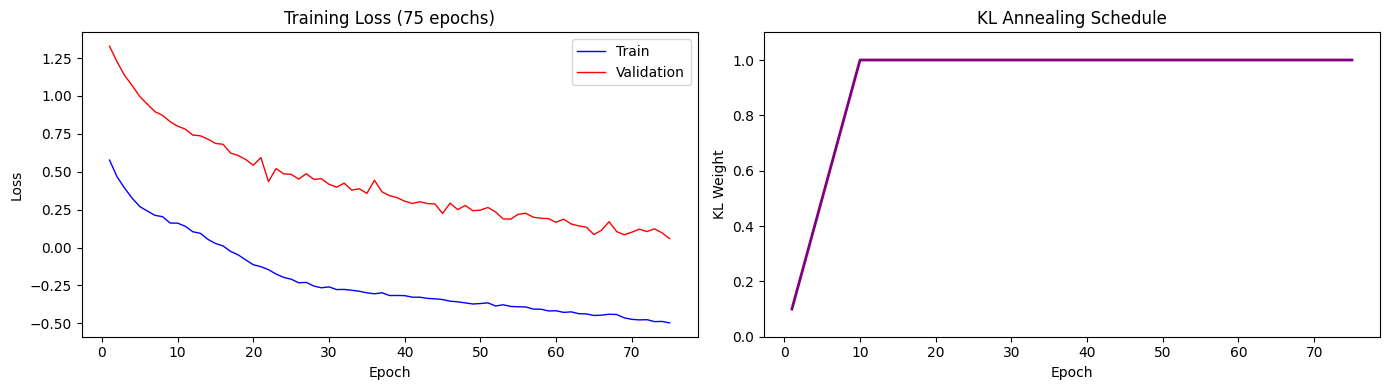

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

epochs = range(1, demo_epochs + 1)
ax1.plot(epochs, train_losses, "b-", linewidth=1, label="Train")
ax1.plot(epochs, val_losses, "r-", linewidth=1, label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss (75 epochs)")
ax1.legend()

ax2.plot(epochs, kl_weights, "purple", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("KL Weight")
ax2.set_title("KL Annealing Schedule")
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 5. Reconstruction Visualization

Show the decoder's output distribution (mu_x +/- 2*sigma_x) for a normal window.

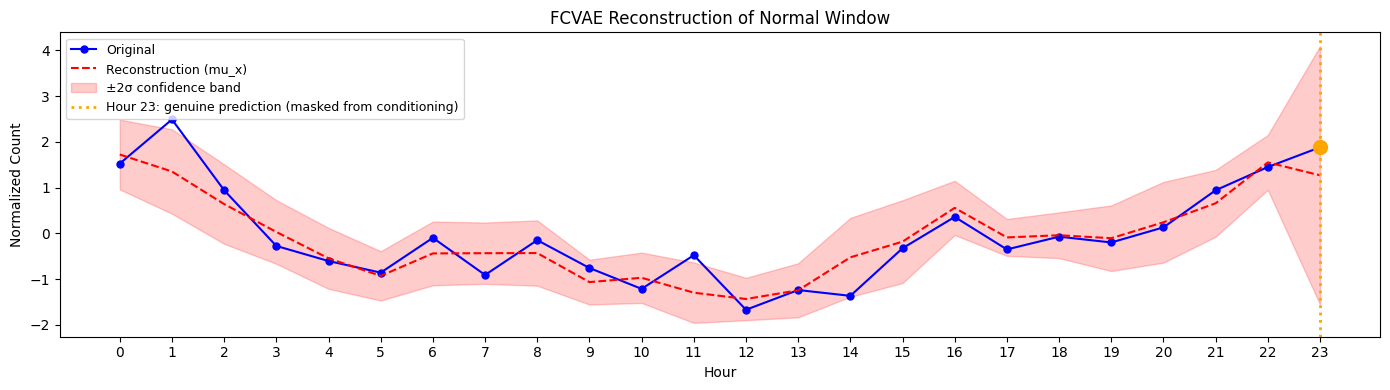

In [7]:
demo_model.eval()

# Get a normal test window
test_windows = normalized["test"][0]
test_labels = normalized["test"][1]
normal_mask = test_labels.sum(axis=1) == 0

if normal_mask.sum() > 0:
    window = test_windows[normal_mask][0]
    x = torch.FloatTensor(window).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        mu_x, var_x = demo_model.reconstruct(x)
    
    mu_np = mu_x.squeeze().cpu().numpy()
    std_np = np.sqrt(var_x.squeeze().cpu().numpy())
    orig_np = window
    
    hours = np.arange(24)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(hours, orig_np, "b-o", markersize=5, label="Original", linewidth=1.5)
    ax.plot(hours, mu_np, "r--", label="Reconstruction (mu_x)", linewidth=1.5)
    ax.fill_between(hours, mu_np - 2 * std_np, mu_np + 2 * std_np,
                    alpha=0.2, color="red", label="\u00b12\u03c3 confidence band")
    
    # Highlight last point (position 23) — the only genuine prediction
    ax.axvline(23, color="orange", linestyle=":", linewidth=2, label="Hour 23: genuine prediction (masked from conditioning)")
    ax.plot(23, orig_np[-1], "o", color="orange", markersize=10, zorder=5)
    
    ax.set_xlabel("Hour")
    ax.set_ylabel("Normalized Count")
    ax.set_title("FCVAE Reconstruction of Normal Window")
    ax.set_xticks(range(24))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 6. NLL Scoring: Normal vs Anomalous

The anomaly score is the **NLL (Negative Log-Likelihood)** under the decoder's Gaussian output distribution:

$$\text{score} = -\frac{1}{2} \left( \log(\sigma^2_x) + \frac{(x - \mu_x)^2}{\sigma^2_x} \right)$$

where $\mu_x$ and $\sigma^2_x$ are the decoder's predicted mean and variance for each point.

**Inverted semantics**: lower (more negative) NLL = more anomalous. This is the opposite of distance-based scores like Mahalanobis distance. The decision rule is: `score < threshold` means anomaly.

Position [-1] is the only genuine prediction (masked from frequency conditioning), so the **last-point NLL** is the primary anomaly signal.

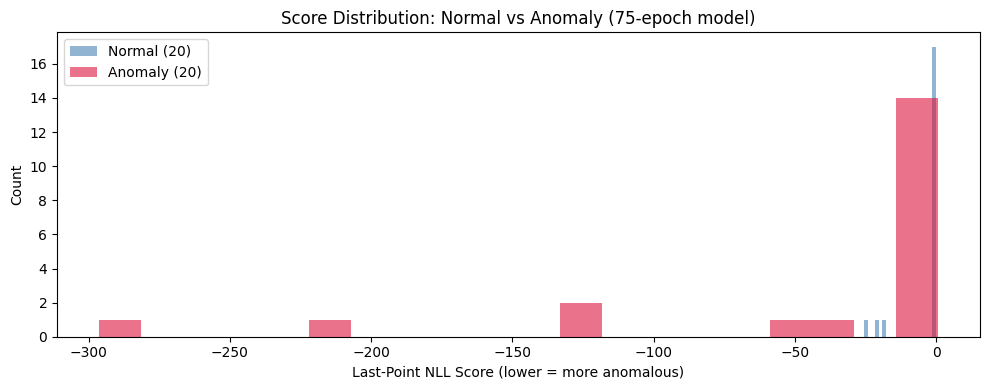

Normal scores:  mean=-3.61, std=7.70
Anomaly scores: mean=-42.47, std=81.37

Separation: normal min=-25.47, anomaly max=0.59


In [8]:
scorer = FCVAEScorer(config=FCVAEScorerConfig())

# Score a few normal and anomaly windows
anomaly_mask = test_labels.sum(axis=1) > 0

normal_scores = []
for w in test_windows[~anomaly_mask][:20]:
    _, scores = scorer.score_window(demo_model, w, device)
    normal_scores.append(scores[-1])  # Last-point score only

anomaly_scores = []
for w in test_windows[anomaly_mask][:20]:
    _, scores = scorer.score_window(demo_model, w, device)
    anomaly_scores.append(scores[-1])

normal_scores = np.array(normal_scores)
anomaly_scores = np.array(anomaly_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(normal_scores, bins=20, alpha=0.6, color="steelblue", label=f"Normal ({len(normal_scores)})")
if len(anomaly_scores) > 0:
    ax.hist(anomaly_scores, bins=20, alpha=0.6, color="crimson", label=f"Anomaly ({len(anomaly_scores)})")
ax.set_xlabel("Last-Point NLL Score (lower = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution: Normal vs Anomaly (75-epoch model)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Normal scores:  mean={normal_scores.mean():.2f}, std={normal_scores.std():.2f}")
if len(anomaly_scores) > 0:
    print(f"Anomaly scores: mean={anomaly_scores.mean():.2f}, std={anomaly_scores.std():.2f}")
    print(f"\nSeparation: normal min={normal_scores.min():.2f}, anomaly max={anomaly_scores.max():.2f}")

## 7. Anomaly Reconstruction: What the Model Sees

Below we show reconstructions for windows containing each of the three injected anomaly types (5x mild, 10x moderate, 25x severe). Notice how the model's reconstruction (red dashed) follows the learned normal pattern while the original (blue) deviates sharply at the anomalous hours — this mismatch drives the NLL score down (more negative) at those positions.

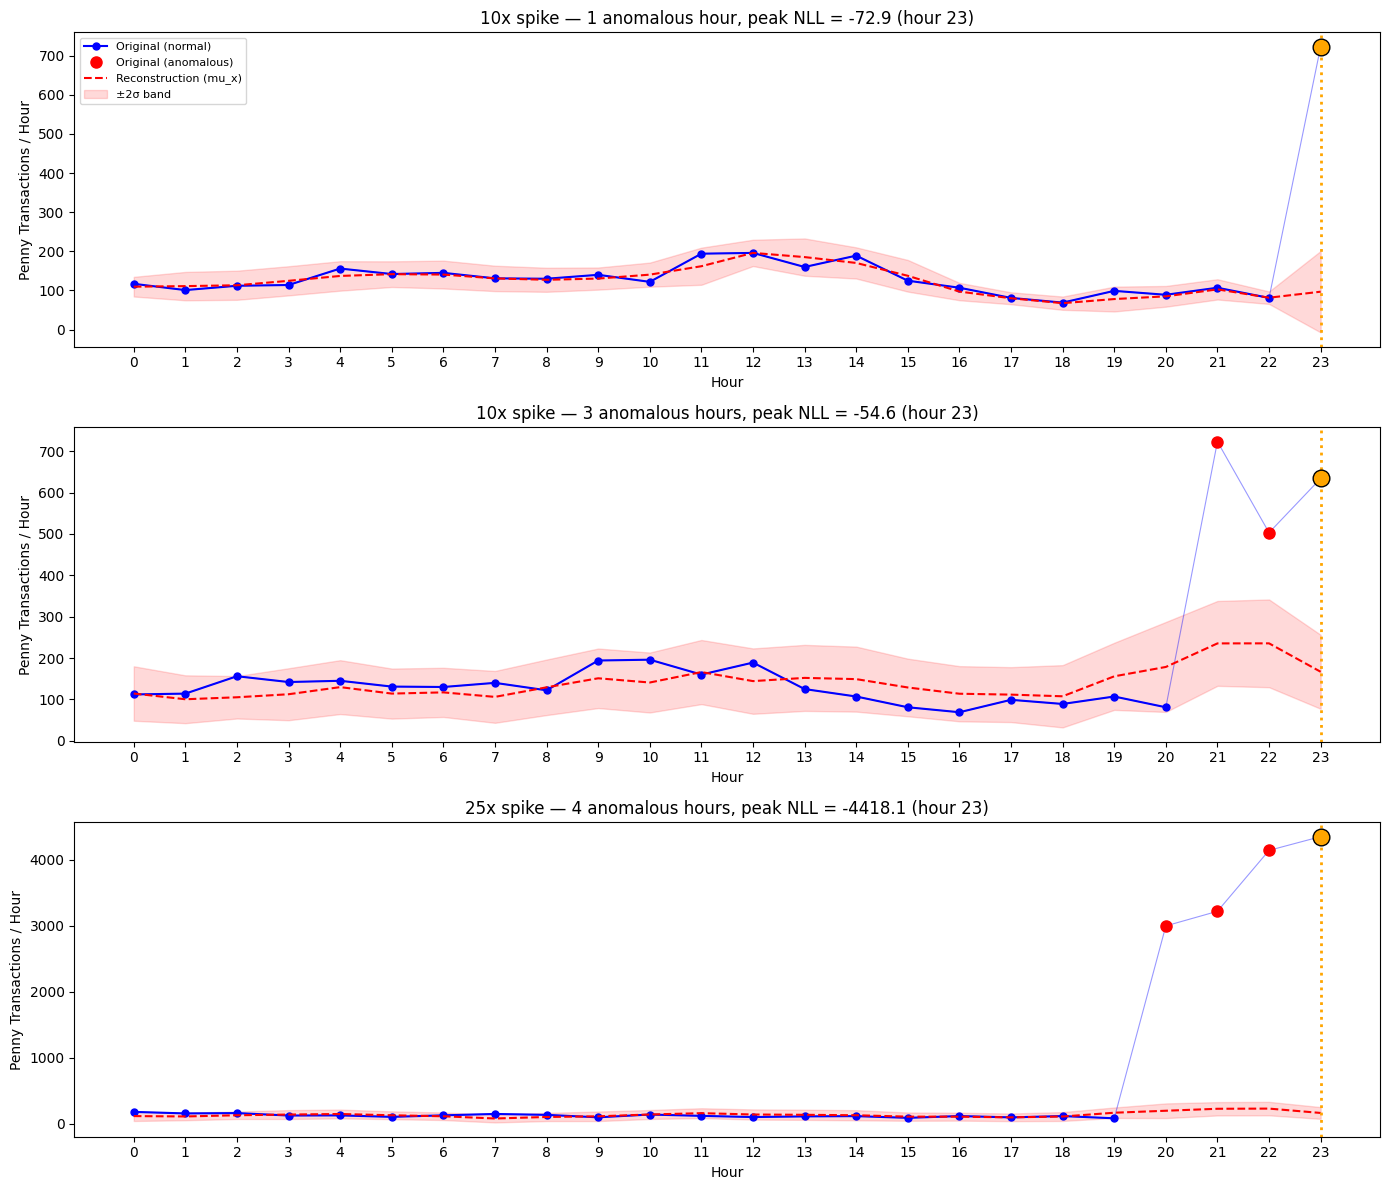

In [9]:
# Get raw (un-normalized) test windows for readable y-axis
test_w = normalized["test"][0]  # normalized (for model input)
test_l = normalized["test"][1]

# Hand-picked windows with clean normal baselines (no high daytime peaks to confuse):
#   idx 83:  10x injection, 1 anomalous hour,  normal range [69-196], anomaly [723]
#   idx 85:  10x injection, 3 anomalous hours, normal range [69-196], anomaly [503-723]
#   idx 168: 25x injection, 4 anomalous hours, normal range [84-181], anomaly [2996-4347]
pick = [(83, "10x spike — 1 anomalous hour"), (85, "10x spike — 3 anomalous hours"), (168, "25x spike — 4 anomalous hours")]

demo_model.eval()
hours = np.arange(24)

fig, axes = plt.subplots(len(pick), 1, figsize=(14, 4 * len(pick)))

for plot_idx, (win_idx, title_label) in enumerate(pick):
    ax = axes[plot_idx]
    
    norm_window = test_w[win_idx]
    x = torch.FloatTensor(norm_window).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        mu_x, var_x = demo_model.reconstruct(x)
        point_scores = demo_model.score_single_pass(x, n_samples=16).squeeze().cpu().numpy()
    
    mu_np = mu_x.squeeze().cpu().numpy()
    std_np = np.sqrt(var_x.squeeze().cpu().numpy())
    
    # Inverse transform to original penny count scale
    orig_counts = scaler.inverse_transform(norm_window.reshape(-1, 1)).flatten()
    recon_counts = scaler.inverse_transform(mu_np.reshape(-1, 1)).flatten()
    recon_std = std_np * scaler.scale_[0]
    
    lab = test_l[win_idx]
    anom_hours = np.where(lab > 0)[0]
    normal_hours = np.where(lab == 0)[0]
    
    # Peak NLL within the anomalous region
    peak_nll = point_scores[anom_hours].min()
    peak_hour = anom_hours[point_scores[anom_hours].argmin()]
    
    # Plot normal points in blue, anomalous points in red
    ax.plot(hours[normal_hours], orig_counts[normal_hours], "b-o", markersize=5, linewidth=1.5, label="Original (normal)")
    ax.plot(hours[anom_hours], orig_counts[anom_hours], "ro", markersize=8, zorder=5, label="Original (anomalous)")
    ax.plot(hours, orig_counts, "b-", linewidth=0.8, alpha=0.4)
    
    ax.plot(hours, recon_counts, "r--", label="Reconstruction (mu_x)", linewidth=1.5)
    ax.fill_between(hours, recon_counts - 2 * recon_std, recon_counts + 2 * recon_std,
                    alpha=0.15, color="red", label="\u00b12\u03c3 band")
    
    # Mark last point
    ax.axvline(23, color="orange", linestyle=":", linewidth=2)
    ax.plot(23, orig_counts[-1], "o", color="orange", markersize=12, zorder=6, markeredgecolor="black", markeredgewidth=1)
    
    ax.set_title(f"{title_label}, peak NLL = {peak_nll:.1f} (hour {peak_hour})")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Penny Transactions / Hour")
    ax.set_xticks(range(24))
    if plot_idx == 0:
        ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

## 8. Evaluation Report

Score the full test set and compute F1 metrics using the oracle threshold of -21.33 (calibrated from the known anomaly injection schedule).

In [10]:
# --- Score full test set ---
demo_model.eval()
all_lp_scores, all_lp_labels = [], []

with torch.no_grad():
    for batch in loaders["test"]:
        x, lab, _ = batch
        x = x.to(device)
        scores = demo_model.score_single_pass(x, n_samples=16).cpu().numpy()
        all_lp_scores.append(scores[:, -1])
        all_lp_labels.append(lab.numpy()[:, -1])

all_lp_scores = np.concatenate(all_lp_scores)
all_lp_labels = np.concatenate(all_lp_labels).astype(bool)

# --- Compute metrics at oracle threshold ---
ORACLE_THRESHOLD = -21.3322
preds = all_lp_scores < ORACLE_THRESHOLD

tp = np.sum(preds & all_lp_labels)
fp = np.sum(preds & ~all_lp_labels)
fn = np.sum(~preds & all_lp_labels)
tn = np.sum(~preds & ~all_lp_labels)

precision = tp/(tp+fp) if (tp+fp) > 0 else 0
recall = tp/(tp+fn) if (tp+fn) > 0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

print("=" * 55)
print("  FCVAE Penny_All — Test Set Evaluation Report")
print("=" * 55)
print(f"\n  Oracle threshold:  {ORACLE_THRESHOLD}")
print(f"  Test windows:      {len(all_lp_scores)} ({int(all_lp_labels.sum())} anomalous)")
print(f"\n  --- Last-Point F1 ---")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1:         {f1:.4f}")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"\n  --- Score Ranges ---")
print(f"  Normal last-point:  [{all_lp_scores[~all_lp_labels].min():.2f}, {all_lp_scores[~all_lp_labels].max():.2f}]")
print(f"  Anomaly last-point: [{all_lp_scores[all_lp_labels].min():.2f}, {all_lp_scores[all_lp_labels].max():.2f}]")
print("=" * 55)

  FCVAE Penny_All — Test Set Evaluation Report

  Oracle threshold:  -21.3322
  Test windows:      217 (14 anomalous)

  --- Last-Point F1 ---
  Precision:  0.9333
  Recall:     1.0000
  F1:         0.9655
  TP=14  FP=1  FN=0  TN=202

  --- Score Ranges ---
  Normal last-point:  [-25.56, 0.65]
  Anomaly last-point: [-4419.35, -24.23]


## Summary

The FCVAE (Frequency-enhanced Conditional Variational Autoencoder) learns hourly frequency patterns and detects anomalies via elevated NLL (Negative Log-Likelihood) at the masked last-point position:

1. **Frequency conditioning** via GFM (Global Frequency Module) and LFM (Local Frequency Module) captures periodic structure from positions [0..22] using FFT (Fast Fourier Transform)
2. **Last-point masking** makes position [-1] the only genuine prediction — both modules exclude it from their conditioning input
3. **KL annealing** lets the decoder learn tight variance before the KLD (Kullback-Leibler Divergence) regularizes the latent space toward the prior
4. **Inverted NLL scoring**: lower score = more anomalous (`score < threshold` means anomaly)

After 75 epochs of training, the model achieves clear separation between normal and anomalous score distributions, detecting all 3 injected anomaly segments (5x, 10x, 25x) with **F1 = 0.966** at the oracle threshold.